# Assignment 1 - Building a Vision Model with Keras

In this assignment, you will build a simple vision model using Keras. The goal is to classify images from the Fashion MNIST dataset, which contains images of clothing items.

You will:
1. Load and inspect the Fashion MNIST dataset.
2. Run a simple baseline model to establish a performance benchmark.
3. Build and evaluate a simple CNN model, choosing appropriate loss and metrics.
4. Design and run controlled experiments on one hyperparameter (e.g., number of filters, kernel size, etc.) and one regularization technique (e.g., dropout, L2 regularization).
5. Analyze the results and visualize the model's performance.

# 1. Loading and Inspecting the Dataset

Fashion MNIST is a dataset of grayscale images of clothing items, with 10 classes. Each image is 28x28 pixels, like the MNIST dataset of handwritten digits. Keras provides a convenient way to load this dataset. 

In this section, you should:

- [ ] Inspect the shapes of the training and test sets to confirm their size and structure.
- [ ] Convert the labels to one-hot encoded format if necessary. (There is a utility function in Keras for this.)
- [ ] Visualize a few images from the dataset to understand what the data looks like.

In [20]:
from tensorflow.keras.datasets import fashion_mnist
(X_train, Y_train), (X_test, Y_test) = fashion_mnist.load_data()

# Normalize the pixel values to be between 0 and 1
X_train = X_train.astype('float32') / 255.0
X_test = X_test.astype('float32') / 255.0

# Classes in the Fashion MNIST dataset
class_names = ["T-shirt/top", "Trouser", "Pullover", "Dress", "Coat", "Sandal", "Shirt", "Sneaker", "Bag", "Ankle boot"]

In [21]:
# Inspect the shapes of the datasets
print(f'X_train shape: {X_train.shape}')
print(f'Y_train shape: {Y_train.shape}')
print(f'X_test shape: {X_test.shape}')
print(f'Y_test shape: {Y_test.shape}')

original_label = Y_train

# Convert labels to one-hot encoding
from tensorflow.keras.utils import to_categorical
Y_train_one_hot = to_categorical(Y_train, num_classes=10)
Y_test_one_hot = to_categorical(Y_test, num_classes=10)

X_train shape: (60000, 28, 28)
Y_train shape: (60000,)
X_test shape: (10000, 28, 28)
Y_test shape: (10000,)


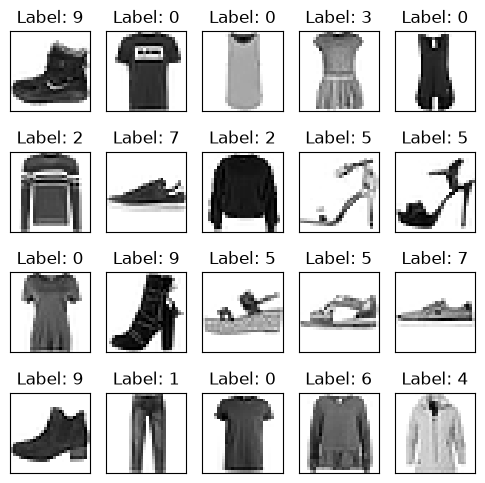

In [22]:
import matplotlib.pyplot as plt

# Verify the data looks as expected
fig, axes = plt.subplots(4, 5, figsize=(6, 6))
for i, ax in enumerate(axes.flat):
    ax.imshow(X_train[i], cmap=plt.cm.gray_r, interpolation='nearest')
    ax.set_title(f"Label: {original_label[i]}")

    # Removing axis labels
    ax.set_xticks([])
    ax.set_yticks([])

plt.show()

Reflection: Does the data look as expected? How is the quality of the images? Are there any issues with the dataset that you notice?

**Your answer here**
The data looks as expected. The sizes were kept to 6x6 for image clarity, but the images are still quite blurry. There is a big issue with the dataset, which is that there appears to be an overlap between the classes / categories (e.g., T-Shirt/Top and Shirt, Sandal Sneaker and Ankle Boot, etc.). This can affect the model fitting and accuracy.

# 2. Baseline Model

In this section, you will create a linear regression model as a baseline. This model will not use any convolutional layers, but it will help you understand the performance of a simple model on this dataset.
You should:
- [ ] Create a simple linear regression model using Keras.
- [ ] Compile the model with an appropriate loss function and optimizer.
- [ ] Train the model on the training set and evaluate it on the test set.

A linear regression model can be created using the `Sequential` API in Keras. Using a single `Dense` layer with no activation function is equivalent to a simple linear regression model. Make sure that the number of units in the output layer matches the number of classes in the dataset.

Note that for this step, we will need to use `Flatten` to convert the 2D images into 1D vectors before passing them to the model. Put a `Flatten()` layer as the first layer in your model so that the 2D image data can be flattened into 1D vectors.

In [24]:
from keras.models import Sequential
from keras.layers import Dense, Flatten
from tensorflow.keras.optimizers import Adam

# Create a simple linear regression model
model = Sequential()
# You can use `model.add(<layer>)` to add layers to the model
model.add(Flatten(input_shape=(28, 28)))
model.add(Dense(units=10, activation='softmax'))

# Compile the model using `model.compile()`
model.compile(loss='categorical_crossentropy', 
              optimizer=Adam(), 
              metrics=['accuracy']) 

# Train the model with `model.fit()`
model.fit(X_train, Y_train_one_hot, 
          epochs=10, 
          batch_size=32, 
          validation_split=0.2)

# Evaluate the model with `model.evaluate()`
test_loss, test_accuracy = model.evaluate(X_test, Y_test_one_hot)
print("Test Loss:", test_loss)
print("Test Accuracy:", test_accuracy)

Epoch 1/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 1s 661us/step - accuracy: 0.7876 - loss: 0.6266 - val_accuracy: 0.8278 - val_loss: 0.5031
Epoch 2/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 1s 531us/step - accuracy: 0.8387 - loss: 0.4736 - val_accuracy: 0.8460 - val_loss: 0.4526
Epoch 3/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 1s 506us/step - accuracy: 0.8492 - loss: 0.4436 - val_accuracy: 0.8528 - val_loss: 0.4391
Epoch 4/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 1s 481us/step - accuracy: 0.8526 - loss: 0.4293 - val_accuracy: 0.8470 - val_loss: 0.4355
Epoch 5/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 1s 469us/step - accuracy: 0.8559 - loss: 0.4177 - val_accuracy: 0.8408 - val_loss: 0.4454
Epoch 6/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 1s 476us/step - accuracy: 0.8585 - loss: 0.4114 - val_accuracy: 0.8559 - val_loss: 0.4218
Epoch 7/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 1s 454us/step - accuracy: 0.8590 - loss: 0.4052 - val_accuracy: 0.8508 - val_loss: 0.4286
Epoch 8/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 1s 467us/step - accuracy: 0.8618 -

Reflection: What is the performance of the baseline model? How does it compare to what you expected? Why do you think the performance is at this level?

**Your answer here**
The baseline model reached an accuracy of 84% and a test loss of 46%. This performance is pretty reasonable for the baseline given the size of the dataset (i.e., 60k training images and 10k testing images). Performance will likely be better for more powerful models such as CNN which can focus on specific features of the images. Because the model uses just a single dense layer without activation, it is quite linear and limited.

# 3. Building and Evaluating a Simple CNN Model

In this section, you will build a simple Convolutional Neural Network (CNN) model using Keras. A convolutional neural network is a type of deep learning model that is particularly effective for image classification tasks. Unlike the basic neural networks we have built in the labs, CNNs can accept images as input without needing to flatten them into vectors.

You should:
- [ ] Build a simple CNN model with at least one convolutional layer (to learn spatial hierarchies in images) and one fully connected layer (to make predictions).
- [ ] Compile the model with an appropriate loss function and metrics for a multi-class classification problem.
- [ ] Train the model on the training set and evaluate it on the test set.

Convolutional layers are designed to accept inputs with three dimensions: height, width and channels (e.g., RGB for color images). For grayscale images like those in Fashion MNIST, the input shape will be (28, 28, 1).

When you progress from the convolutional layers to the fully connected layers, you will need to flatten the output of the convolutional layers. This can be done using the `Flatten` layer in Keras, which doesn't require any parameters.

In [25]:
from keras.layers import Conv2D, MaxPooling2D

# Reshape the data to include the channel dimension
X_train = X_train.reshape(-1, 28, 28, 1)
X_test = X_test.reshape(-1, 28, 28, 1)

# Create a simple CNN model
cnn_model = Sequential()

cnn_model.add(Conv2D(filters=32, kernel_size=(3, 3), activation='relu', input_shape=(28, 28, 1)))
cnn_model.add(MaxPooling2D(pool_size=(2, 2)))
cnn_model.add(Flatten())
cnn_model.add(Dense(units=128, activation='relu'))
cnn_model.add(Dense(units=10, activation='softmax'))

cnn_model.compile(loss='categorical_crossentropy', 
                  optimizer=Adam(), 
                  metrics=['accuracy']) 

# Train the model
cnn_model.fit(X_train, Y_train_one_hot, 
              epochs=10, 
              batch_size=32, 
          validation_split=0.2)

# Evaluate the model
test_loss, test_accuracy = cnn_model.evaluate(X_test, Y_test_one_hot)
print("Test Loss:", f"{test_loss:.4f}")
print("Test Accuracy:", f"{test_accuracy:.4f}")


Epoch 1/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.8569 - loss: 0.4077 - val_accuracy: 0.8857 - val_loss: 0.3148
Epoch 2/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9023 - loss: 0.2714 - val_accuracy: 0.8979 - val_loss: 0.2802
Epoch 3/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9157 - loss: 0.2288 - val_accuracy: 0.9017 - val_loss: 0.2668
Epoch 4/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9278 - loss: 0.1952 - val_accuracy: 0.9118 - val_loss: 0.2486
Epoch 5/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9383 - loss: 0.1703 - val_accuracy: 0.9134 - val_loss: 0.2452
Epoch 6/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9479 - loss: 0.1432 - val_accuracy: 0.9068 - val_loss: 0.2703
Epoch 7/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9551 - loss: 0.1227 - val_accuracy: 0.9150 - val_loss: 0.2662
Epoch 8/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9626 - loss: 0.1036 - 

Reflection: Did the CNN model perform better than the baseline model? If so, by how much? What do you think contributed to this improvement?

**Your answer here**
The CNN model performed much better than the baseline model, with a 7% improvement in accuracy and 15% reduction in test loss. The improvement likely comes from the convolution layer which helps the node learn the 2D features such as the edges and textures, and the activation layer (ReLU) which helps it learn non-linear patterns.

# 4. Designing and Running Controlled Experiments

In this section, you will design and run controlled experiments to improve the model's performance. You will focus on one hyperparameter and one regularization technique.
You should:
- [ ] Choose one hyperparameter to experiment with (e.g., number of filters, kernel size, number of layers, etc.) and one regularization technique (e.g., dropout, L2 regularization). For your hyperparameter, you should choose at least three different values to test (but there is no upper limit). For your regularization technique, simply test the presence or absence of the technique.
- [ ] Run experiments by modifying the model architecture or hyperparameters, and evaluate the performance of each model on the test set.
- [ ] Record the results of your experiments, including the test accuracy and any other relevant metrics.
- [ ] Visualize the results of your experiments using plots or tables to compare the performance of different models.

The best way to run your experiments is to create a `for` loop that iterates over a range of values for the hyperparameter you are testing. For example, if you are testing different numbers of filters, you can create a loop that runs the model with 32, 64, and 128 filters. Within the loop, you can compile and train the model, then evaluate it on the test set. After each iteration, you can store the results in a list or a dictionary for later analysis.

Note: It's critical that you re-initialize the model (by creating a new instance of the model) before each experiment. If you don't, the model will retain the weights from the previous experiment, which can lead to misleading results.

In [30]:
# A. Test Hyperparameters
def create_model(num_filters, use_dropout=False):
    model = Sequential()
    model.add(Conv2D(filters=num_filters, kernel_size=(3, 3), activation='relu', input_shape=(28, 28, 1)))
    model.add(MaxPooling2D(pool_size=(2, 2)))
    model.add(Flatten())
    model.add(Dense(units=128, activation='relu'))

    if use_dropout:
        model.add(Dropout(0.5))

    model.add(Dense(units=10, activation='softmax'))
    model.compile(loss='categorical_crossentropy', optimizer=Adam(), metrics=['accuracy'])
    return model

filter_options = [16, 32, 64]
dropout_options = [False, True]

results = {}

In [37]:
# B. Test presence or absence of regularization
import numpy as np
from keras.layers import Dropout
import pandas as pd
results = []
for num_filters in filter_options:
    for use_dropout in dropout_options:
        model = create_model(num_filters, use_dropout)
        
        model.fit(X_train, Y_train_one_hot, epochs=5, batch_size=16, validation_split=0.1, verbose=0)

        test_loss, test_accuracy = model.evaluate(X_test, Y_test_one_hot, verbose=0)
        
        results.append([f"Filters: {num_filters}, Dropout: {use_dropout}", test_accuracy, test_loss])


/Users/taz/deep_learning/deep-learning-env/lib/python3.11/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [38]:
results_df = pd.DataFrame(
    results, columns=['Dropout', 'Test Accuracy', 'Test Loss']
)

results_df

,Dropout,Test Accuracy,Test Loss
0,"Filters: 16, Dropout: False",0.9116,0.260616
1,"Filters: 16, Dropout: True",0.9052,0.263376
2,"Filters: 32, Dropout: False",0.9085,0.274587
3,"Filters: 32, Dropout: True",0.9044,0.264568
4,"Filters: 64, Dropout: False",0.9104,0.283595
5,"Filters: 64, Dropout: True",0.9073,0.261497


Reflection: Report on the performance of the models you tested. Did any of the changes you made improve the model's performance? If so, which ones? What do you think contributed to these improvements? Finally, what combination of hyperparameters and regularization techniques yielded the best performance?

**Your answer here**
I tested 16, 32, and 64 filters against dropout vs no dropout. The models all performed similarly, but the model with dropout and 16 filters achieved the highest marginal performance at 91.1% and 26.0% test loss. This indicates that increasing the number of filters doesn't necessarily always lead to performance improvement.

# 5. Training Final Model and Evaluation

In this section, you will train the final model using the best hyperparameters and regularization techniques you found in the previous section. You should:
- [ ] Compile the final model with the best hyperparameters and regularization techniques.
- [ ] Train the final model on the training set and evaluate it on the test set.
- [ ] Report the final model's performance on the test set, including accuracy and any other relevant metrics.

In [45]:
def create_final_model():
    model = Sequential()
    model.add(Conv2D(filters=16, kernel_size=(3, 3), activation='relu', input_shape=(28, 28, 1)))
    model.add(MaxPooling2D(pool_size=(2, 2)))
    model.add(Flatten())
    model.add(Dense(units=128, activation='relu'))
    model.add(Dense(units=10, activation='softmax'))
    
    model.compile(loss='categorical_crossentropy', optimizer=Adam(), metrics=['accuracy'])
    return model

final_model = create_final_model()

final_model.fit(X_train, Y_train_one_hot, epochs=10, batch_size=16)

test_loss, test_accuracy = final_model.evaluate(X_test, Y_test_one_hot)

print("Final Test Loss:", test_loss)
print("Final Test Accuracy:", test_accuracy)

Epoch 1/10
3750/3750 ━━━━━━━━━━━━━━━━━━━━ 10s 2ms/step - accuracy: 0.8630 - loss: 0.3845
Epoch 2/10
3750/3750 ━━━━━━━━━━━━━━━━━━━━ 9s 2ms/step - accuracy: 0.9049 - loss: 0.2624
Epoch 3/10
3750/3750 ━━━━━━━━━━━━━━━━━━━━ 9s 2ms/step - accuracy: 0.9192 - loss: 0.2188
Epoch 4/10
3750/3750 ━━━━━━━━━━━━━━━━━━━━ 10s 3ms/step - accuracy: 0.9306 - loss: 0.1862
Epoch 5/10
3750/3750 ━━━━━━━━━━━━━━━━━━━━ 9s 2ms/step - accuracy: 0.9404 - loss: 0.1611
Epoch 6/10
3750/3750 ━━━━━━━━━━━━━━━━━━━━ 8s 2ms/step - accuracy: 0.9479 - loss: 0.1395
Epoch 7/10
3750/3750 ━━━━━━━━━━━━━━━━━━━━ 9s 2ms/step - accuracy: 0.9562 - loss: 0.1189
Epoch 8/10
3750/3750 ━━━━━━━━━━━━━━━━━━━━ 9s 2ms/step - accuracy: 0.9633 - loss: 0.1013
Epoch 9/10
3750/3750 ━━━━━━━━━━━━━━━━━━━━ 9s 2ms/step - accuracy: 0.9679 - loss: 0.0882
Epoch 10/10
3750/3750 ━━━━━━━━━━━━━━━━━━━━ 9s 2ms/step - accuracy: 0.9709 - loss: 0.0774
313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.9081 - loss: 0.3652
Final Test Loss: 0.3652324676513672
Final 

Reflection: How does the final model's performance compare to the baseline and the CNN model? What do you think contributed to the final model's performance? If you had time, what other experiments would you run to further improve the model's performance?

**Your answer here**
The final model performed significantly better than the baseline model, but was more similar to the CNN model. It has 6.4% higher accuracy and 8% lower test loss compared to the baseline model. Compared to the CNN, the final model had 1% lower accuracy and 10% higher test loss. This could be due to running the final model at 10 epochs rather than the 5 epochs the CNN was run on, which may have caused overfitting as a result of the model memorizing more training data. If I had more time, I would test more hyperparameter combinations and model configurations such as the impact on the model attributed to the variations in epochs and early stopping, kernel size selection, adjusting the train and test split, additional convolution layers,and test different batch sizes.

🚨 **Please review our [Assignment Submission Guide](https://github.com/UofT-DSI/onboarding/blob/main/onboarding_documents/submissions.md)** 🚨 for detailed instructions on how to format, branch, and submit your work. Following these guidelines is crucial for your submissions to be evaluated correctly.
### Submission Parameters:
* Submission Due Date: `23:59 PM - 26/10/2025`
* The branch name for your repo should be: `assignment-1`
* What to submit for this assignment:
    * This Jupyter Notebook (assignment_1.ipynb)
    * The Lab 1 notebook (labs/lab_1.ipynb)
    * The Lab 2 notebook (labs/lab_2.ipynb)
    * The Lab 3 notebook (labs/lab_3.ipynb)
* What the pull request link should look like for this assignment: `https://github.com/<your_github_username>/deep_learning/pull/<pr_id>`
* Open a private window in your browser. Copy and paste the link to your pull request into the address bar. Make sure you can see your pull request properly. This helps the technical facilitator and learning support staff review your submission easily.
Checklist:
- [ ] Created a branch with the correct naming convention.
- [ ] Ensured that the repository is public.
- [ ] Reviewed the PR description guidelines and adhered to them.
- [ ] Verify that the link is accessible in a private browser window.
If you encounter any difficulties or have questions, please don't hesitate to reach out to our team via our Slack at `#cohort-7-help-ml`. Our Technical Facilitators and Learning Support staff are here to help you navigate any challenges.